In [ ]:
# Установка необходимых библиотек
!pip install natasha
!pip install pymorphy2
!pip install matplotlib
!pip install pandas
!pip install -U natasha slovnet navec pymorphy2 matplotlib pandas
!pip uninstall -y natasha slovnet navec nerus
!pip install natasha slovnet navec nerus

Found existing installation: natasha 1.6.0
Uninstalling natasha-1.6.0:
  Successfully uninstalled natasha-1.6.0
Found existing installation: slovnet 0.6.0
Uninstalling slovnet-0.6.0:
  Successfully uninstalled slovnet-0.6.0
Found existing installation: navec 0.10.0
Uninstalling navec-0.10.0:
  Successfully uninstalled navec-0.10.0
Found existing installation: nerus 1.7.0
Uninstalling nerus-1.7.0:
  Successfully uninstalled nerus-1.7.0
  Using cached natasha-1.6.0-py3-none-any.whl.metadata (23 kB)
  Using cached slovnet-0.6.0-py3-none-any.whl.metadata (34 kB)
  Using cached navec-0.10.0-py3-none-any.whl.metadata (21 kB)
  Using cached nerus-1.7.0-py3-none-any.whl.metadata (48 kB)
Using cached natasha-1.6.0-py3-none-any.whl (34.4 MB)
Using cached slovnet-0.6.0-py3-none-any.whl (46 kB)
Using cached navec-0.10.0-py3-none-any.whl (23 kB)
Using cached nerus-1.7.0-py3-none-any.whl (15 kB)


In [ ]:
from datasets import load_dataset
from typing import List
import re

from natasha import (
    Segmenter,
    MorphVocab,
    NewsMorphTagger,
    NewsSyntaxParser,
    NewsEmbedding,
    Doc
)
from pymorphy2 import MorphAnalyzer

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter

In [ ]:
df = load_dataset("Milana/russian-indi-alternative", split="train")
print(df)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['artist', 'song_name', 'lyrics'],
    num_rows: 8429
})


In [ ]:
df = df.to_pandas()
df = df.drop(columns=["artist", "song_name"])


In [ ]:
print(df)

                                                 lyrics
0     Дома свет, но\nНепонятно куда\nГонит меня\nМоя...
1     Сирин, волшебная птица\nУкрадёт твои лица\nА в...
2     Тело твоё - не твое\nЗа зрачками не видно дна\...
3     Мне с каждым днём сложнее\nВспоминать твои чер...
4     Вонзила нож в твою спину\nРастоптала твои сны\...
...                                                 ...
8424  Когда ты смотришь на меня\nЯ вспоминаю, кто я ...
8425  Слепили бабу на морозе, руки, ноги, голова\nОн...
8426  Ты прекрасная Кассиопея\nНе признала меня ты ч...
8427  Ты ровесница этого века\nЯ ровесник вчерашней ...
8428  I think we'll be okay\n'Cause i feel it\nFeel ...

[8429 rows x 1 columns]


In [ ]:
df["lyrics"][0]

'Дома свет, но\nНепонятно куда\nГонит меня\nМоя беда\n\nАмок, амок\nДверь на замок\nАмок, Амок\nБеги со всех ног\n\nДома свет, но\nОтчего-то мой взор\nВ даль летел\nБез страха\nАмок, амок\nДверь на замок\nАмок, Амок\nБеги со всех ног\n\nНе кради мою бурю, не кради\nНе кради мой ветер, не кради\nНе кради мою радость, уходи\nИ печаль мою тоже не кради\n\nПятно, пятно, чёрное пятно\nПеред глазами оно\nИ не видно ничего\nКроме чёрного его\nПятно, пятно, чёрное пятно\nПеред глазами одно\nИ не видно ничего\nКроме чёрного его\n\nАмок\n\nЗабываю себя, забываю свой дом\nВремена года и день за днём\nГде идёт, всё идёт\nСвоим чередом\nГонит, гонит, гонит ,гонит, гонит, гонит\nВ огонь\nВ полыхающий зной амок гонит меня\nПотеряться, стать злой\nВ омут броситься с головой\nСтать темной рекой\nИ сгореть, став золой\nЗабываю себя, забываю свой дом\nЗабываю себя, забываю свой дом\nYou might also likeЗабываю себя, забываю свой дом\nВремена года и день за днём\nГде идёт, всё идёт\nСвоим чередом\nГонит, г

In [ ]:
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)
morph = MorphAnalyzer()

In [ ]:
print(df)


                                                 lyrics
0     Дома свет, но\nНепонятно куда\nГонит меня\nМоя...
1     Сирин, волшебная птица\nУкрадёт твои лица\nА в...
2     Тело твоё - не твое\nЗа зрачками не видно дна\...
3     Мне с каждым днём сложнее\nВспоминать твои чер...
4     Вонзила нож в твою спину\nРастоптала твои сны\...
...                                                 ...
8424  Когда ты смотришь на меня\nЯ вспоминаю, кто я ...
8425  Слепили бабу на морозе, руки, ноги, голова\nОн...
8426  Ты прекрасная Кассиопея\nНе признала меня ты ч...
8427  Ты ровесница этого века\nЯ ровесник вчерашней ...
8428  I think we'll be okay\n'Cause i feel it\nFeel ...

[8429 rows x 1 columns]


In [ ]:
def parse_sentence(sentence, segmenter, morph_tagger, syntax_parser, morph_vocab):
    doc = Doc(sentence)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    doc.parse_syntax(syntax_parser)

    # Лемматизация всех токенов
    for token in doc.tokens:
        token.lemmatize(morph_vocab)

    subject = None
    predicate = None

    tokens = doc.sents[0].tokens

    for token in tokens:
        if token.rel in ('nsubj', 'nsubj:pass'):
            subject = token.lemma  # ← lemma вместо text
        if token.rel == 'root':
            predicate = token.lemma  # ← lemma вместо text

    return (subject, predicate)

In [ ]:
all_lines = []
for lyrics in df["lyrics"]:
    lines = [line.strip() for line in lyrics.split("\n") if line.strip()]
    all_lines.extend(lines)


for line in all_lines[0:50]:
    print(parse_sentence(line, segmenter, morph_tagger, syntax_parser, morph_vocab))

(None, 'дом')
(None, None)
(None, 'гнать')
(None, None)
(None, 'амок')
(None, 'дверь')
(None, 'амок')
(None, 'бежать')
(None, 'дом')
('взор', None)
(None, 'лететь')
(None, 'страх')
(None, 'амок')
(None, 'дверь')
(None, 'амок')
(None, 'бежать')
(None, 'красть')
(None, 'красть')
(None, 'красть')
('печаль', None)
('пятно', None)
(None, 'глаз')
(None, 'видно')
(None, None)
('пятно', None)
(None, 'глаз')
(None, 'видно')
(None, None)
(None, 'амок')
(None, 'забывать')
(None, 'время')
(None, 'идти')
(None, 'черед')
('гнать', None)
(None, 'огонь')
('амок', 'гнать')
(None, 'потеряться')
(None, None)
(None, 'стать')
(None, 'сгореть')
(None, 'забывать')
(None, 'забывать')
('you', 'забывать')
(None, 'время')
(None, 'идти')
(None, 'черед')
('гнать', None)
(None, 'огонь')
(None, 'забывать')
(None, 'забывать')


In [ ]:
def is_predicate(word, morph):
    """
    Проверяет, является ли слово сказуемым.

    Args:
        word: слово для проверки
        morph: объект MorphAnalyzer из pymorphy2

    Returns:
        bool: True если слово является сказуемым
    """
    parsed = morph.parse(word)
    for p in parsed:
        if p.tag.POS in ('VERB', 'INFN', 'PRED', 'PRTS', 'ADJS'):
            return True
    return False

In [ ]:
for line in all_lines[25:35]:
    subj, pred = parse_sentence(line, segmenter, morph_tagger, syntax_parser, morph_vocab)
    if pred:
        check = is_predicate(pred, morph)
        print(f"«{line}»")
        print(f"  Подлежащее: {subj}")
        print(f"  Сказуемое: {pred} → is_predicate: {check}")
        print()

«Перед глазами одно»
  Подлежащее: None
  Сказуемое: глаз → is_predicate: False

«И не видно ничего»
  Подлежащее: None
  Сказуемое: видно → is_predicate: True

«Амок»
  Подлежащее: None
  Сказуемое: амок → is_predicate: False

«Забываю себя, забываю свой дом»
  Подлежащее: None
  Сказуемое: забывать → is_predicate: True

«Времена года и день за днём»
  Подлежащее: None
  Сказуемое: время → is_predicate: False

«Где идёт, всё идёт»
  Подлежащее: None
  Сказуемое: идти → is_predicate: True

«Своим чередом»
  Подлежащее: None
  Сказуемое: черед → is_predicate: False

«В огонь»
  Подлежащее: None
  Сказуемое: огонь → is_predicate: False



In [ ]:
def build_cooccurrence_dependencies(texts, segmenter, morph_tagger, syntax_parser, morph_vocab):
    """
    Строит зависимости совместных употреблений подлежащих и сказуемых.

    Args:
        texts: список предложений
        segmenter, morph_tagger, syntax_parser: объекты из natasha
        morph_vocab: объект MorphVocab из natasha

    Returns:
        Counter: счетчик пар (подлежащее, сказуемое)
    """
    cooccurrences = []


    for sentence in texts:
        subject, predicate = parse_sentence(sentence, segmenter, morph_tagger, syntax_parser, morph_vocab)


        if subject and predicate:
            cooccurrences.append((subject, predicate))


    return Counter(cooccurrences)

In [36]:
def visualize_results(counter: Counter, top_n: int = 20):
    top_pairs = counter.most_common(top_n)

    df_plot = pd.DataFrame(top_pairs, columns=['pair', 'count'])
    df_plot['pair_str'] = df_plot['pair'].apply(lambda x: f"{x[0]}-{x[1]}")
    df_plot['subject'] = df_plot['pair'].apply(lambda x: x[0])
    df_plot['predicate'] = df_plot['pair'].apply(lambda x: x[1])

    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")

    sns.barplot(data=df_plot, y='pair_str', x='count', palette='viridis')

    plt.title(f'Топ-{top_n} сочетаний подлежащее-глагол', fontsize=16, fontweight='bold')
    plt.xlabel('Частота встречаемости', fontsize=12)
    plt.ylabel('Подлежащее - Глагол', fontsize=12)
    plt.tight_layout()

    for i, v in enumerate(df_plot['count']):
        plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')

    plt.show()

/tmp/ipykernel_17777/2238435433.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, y='pair_str', x='count', palette='viridis')


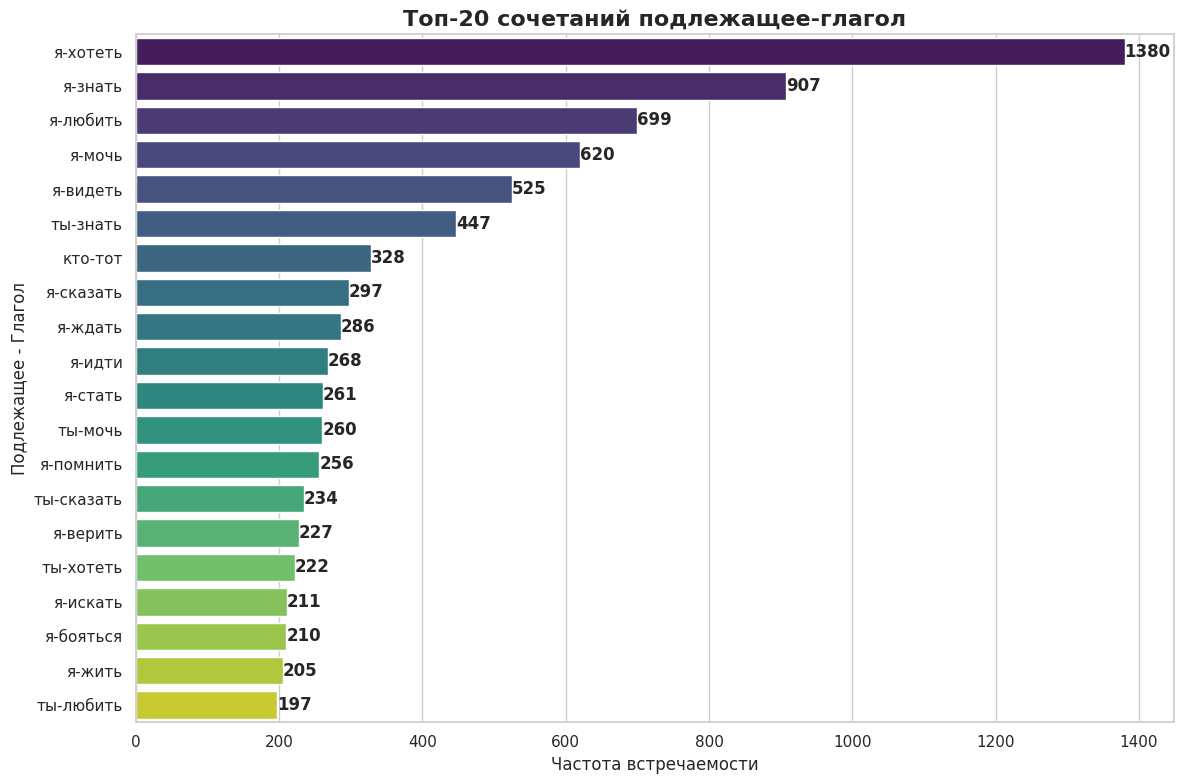

In [37]:

counter = build_cooccurrence_dependencies(all_lines, segmenter, morph_tagger, syntax_parser, morph_vocab)
visualize_results(counter, top_n=20)